In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [212]:
# This helps to run on GPU device 
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [ ]:
# Data augmentation and normalization for CIFAR-10 training and testing
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

In [ ]:
# Loading training and test data 
train_data = datasets.CIFAR10(root = "./data", 
                              train = True, download = True, transform = train_transform)
test_data = datasets.CIFAR10(root = "./data", 
                             train = False, download = True, transform = train_transform)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [215]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               RandomCrop(size=(32, 32), padding=4)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
           )

In [216]:
test_data 

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               RandomCrop(size=(32, 32), padding=4)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
           )

In [ ]:
# Create data loaders for batch processing and model training
train_loader = DataLoader(train_data, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_data, batch_size = 64, shuffle = False)

In [ ]:
# Convolutional layers 
conv1 = nn.Conv2d(3, 32, 3, 1)
conv2 = nn.Conv2d(32, 64, 3, 1)
conv3 = nn.Conv2d(64, 128, 3, 1)
conv4 = nn.Conv2d(128, 128, 3, 1)

In [219]:
X_train, y_train = train_data[0]
x = X_train.unsqueeze(0)
print(x.shape)

torch.Size([1, 3, 32, 32])


In [220]:
x = F.relu(conv1(x))
x.shape

torch.Size([1, 32, 30, 30])

In [221]:
x = F.relu(conv2(x))
x.shape

torch.Size([1, 64, 28, 28])

In [222]:
x = F.max_pool2d(x,2,2)
x.shape

torch.Size([1, 64, 14, 14])

In [223]:
x = F.relu(conv3(x))
x.shape

torch.Size([1, 128, 12, 12])

In [224]:
x = F.relu(conv4(x))
x.shape

torch.Size([1, 128, 10, 10])

In [225]:
x = F.max_pool2d(x,2,2)
x.shape

torch.Size([1, 128, 5, 5])

In [226]:
x = torch.flatten(x, start_dim=1)
x.shape

torch.Size([1, 3200])

In [ ]:
# Building CNN and forward pass 
class CNN_CIFAR10(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.conv3 = nn.Conv2d(64, 128, 3, 1)
        self.conv4 = nn.Conv2d(128, 128, 3, 1)

        self.fc1 = nn.Linear(3200, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        
        self.dropout = nn.Dropout(0.3)

        self.flatten = nn.Flatten()

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2,2)
        X = F.relu(self.conv3(X))
        X = F.relu(self.conv4(X))
        X = F.max_pool2d(X, 2,2)

        X = self.flatten(X)

        X = F.relu(self.fc1(X))
        X = self.dropout(X)
        X = F.relu(self.fc2(X))
        X = self.dropout(X)
        X = self.fc3(X) 

        return F.log_softmax(X, dim=1)

In [ ]:
# Create a instance of model and loss function, optimizer 
torch.manual_seed(42)
model = CNN_CIFAR10().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001, weight_decay = 1e-4)
model 

CNN_CIFAR10(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=3200, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
)

In [ ]:
# Training model 
import time
start_time = time.time()

epochs = 50

for epoch in range(epochs):

    model.train()
    for X_train, y_train in train_loader:

        X_train = X_train.to(device)
        y_train = y_train.to(device)

        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1},  Loss: {loss.item():.4f}")


print("Training time:", time.time() - start_time)

Epoch 1,  Loss: 1.2289
Epoch 2,  Loss: 1.2061
Epoch 3,  Loss: 1.2528
Epoch 4,  Loss: 1.1374
Epoch 5,  Loss: 0.9013
Epoch 6,  Loss: 0.7155
Epoch 7,  Loss: 0.8192
Epoch 8,  Loss: 1.1691
Epoch 9,  Loss: 0.6111
Epoch 10,  Loss: 1.0143
Epoch 11,  Loss: 1.2778
Epoch 12,  Loss: 0.3722
Epoch 13,  Loss: 1.1027
Epoch 14,  Loss: 0.4577
Epoch 15,  Loss: 0.3437
Epoch 16,  Loss: 0.2813
Epoch 17,  Loss: 0.3351
Epoch 18,  Loss: 0.7287
Epoch 19,  Loss: 0.1768
Epoch 20,  Loss: 0.7582
Epoch 21,  Loss: 0.4000
Epoch 22,  Loss: 1.0763
Epoch 23,  Loss: 0.4524
Epoch 24,  Loss: 0.5986
Epoch 25,  Loss: 0.6517
Epoch 26,  Loss: 0.3781
Epoch 27,  Loss: 0.5131
Epoch 28,  Loss: 0.5807
Epoch 29,  Loss: 0.4641
Epoch 30,  Loss: 0.2864
Epoch 31,  Loss: 0.4829
Epoch 32,  Loss: 0.4667
Epoch 33,  Loss: 0.1552
Epoch 34,  Loss: 0.1005
Epoch 35,  Loss: 0.1484
Epoch 36,  Loss: 0.4079
Epoch 37,  Loss: 0.7201
Epoch 38,  Loss: 0.6885
Epoch 39,  Loss: 0.2709
Epoch 40,  Loss: 0.4507
Epoch 41,  Loss: 0.3335
Epoch 42,  Loss: 0.1967
E

In [ ]:
# Evaluate model performance on training data
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for X_train, y_train in train_loader:

        X_train = X_train.to(device)
        y_train = y_train.to(device)

        y_pred = model(X_train)

        predicted = torch.max(y_pred, 1)[1]

        correct += (predicted == y_train).sum().item()
        total += y_train.size(0)

print("Training Accuracy:", correct / total)

Training Accuracy: 0.86146


In [ ]:
# Evaluate model performance on test data
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for X_test, y_test in test_loader:
        
        X_test = X_test.to(device)
        y_test = y_test.to(device)

        y_val = model(X_test)

        predicted = torch.max(y_val, 1)[1]
        correct += (predicted == y_test).sum()
        total += y_test.size(0)

print("Test Accuracy:", correct/total)

Test Accuracy: tensor(0.8163, device='mps:0')


In [ ]:
# Collect true labels and predictions for detailed evaluation (e.g., confusion matrix)
y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for X_test, y_test in test_loader:

        X_test = X_test.to(device)
        y_test = y_test.to(device)

        y_val = model(X_test)
        predicted = torch.max(y_val, 1)[1] 

        y_true.extend(y_test.tolist()) 
        y_pred.extend(predicted.tolist())

In [236]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[800  11  51  15   2   2   6   8  85  20]
 [ 13 911   5   3   1   0   2   4  19  42]
 [ 46   3 738  44  45  29  50  29   9   7]
 [ 21   5  56 647  42 113  38  47  16  15]
 [ 16   0  51  30 772  27  32  63   8   1]
 [  8   1  49  99  28 726  13  72   2   2]
 [  7   3  33  36  19   9 879   6   7   1]
 [ 12   4  25  17  22  22   3 881   7   7]
 [ 33  11   8   5   2   1   0   3 924  13]
 [ 21  54   4   3   0   1   6   6  30 875]]


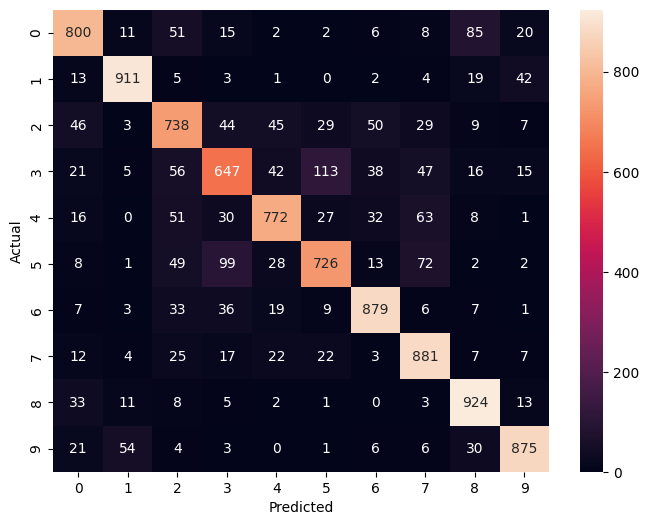

In [ ]:
# Visualization of confusion matrix 
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()